# Analisis Popularitas Topik Lansia di Media Digital

## Data Collection

| Collector | Data |
|-----------|------|
| WHO GHO API | Hipertensi, diabetes, obesitas, harapan hidup (Indonesia) |
| Google Trends | Interest over time + region untuk 5 keyword lansia |
| YouTube Data API v3 | Video engagement + sentimen untuk 8 keyword |

https://github.com/fadilsflow/elderly-health-analytics

 ### Detail per Sumber                                                                                             
                                                                                                                   
 1. WHO (GHO API)                                                                                                  
 - Data historis paling panjang: 1980–2022                                                                         
 - Data tahunan (setiap 1 Januari) — indikator kesehatan lansia di Indonesia                                       
 - Contoh: 1980-01-01, 1990-01-01, ..., 2022-01-01                                                                 
                                                                                                                   
 2. YouTube (Data API v3)                                                                                          
 - Dari 13 Desember 2017 sampai 12 Mei 2026                                                                        
 - Video diambil berdasarkan 5 keyword: kesehatan lansia, lansia, perawatan lansia, posyandu lansia, senam lansia  
 - Collection terakhir: 12 Mei 2026 (sesuai timestamp file)                                                        
                                                                                                                   
 3. Google Trends (pytrends)                                                                                       
 - Dari 1 Mei 2021 sampai 12 Mei 2026                                                                              
 - Data tren pencarian bulanan untuk keyword yang sama      

## Perbandingan Keyword per Media/Source


### 🏥 WHO (GHO API)

| Keyword / Category | Kode Indikator  | Keterangan                 |
| ------------------ | --------------- | -------------------------- |
| Hypertension       | `BP_04`         | Tekanan darah tinggi       |
| Diabetes           | `NCD_GLUC_02`   | Gula darah puasa tinggi    |
| Obesity            | `NCD_BMI_30A`   | Obesitas dewasa (BMI ≥ 30) |
| Life Expectancy    | `WHOSIS_000001` | Angka harapan hidup        |

> WHO tidak menggunakan keyword tekstual, melainkan *indicator code*.
> Digunakan 4 indikator kesehatan yang relevan dengan lansia di Indonesia.

---

### 🎬 YouTube (Data API v3)

| No | Keyword              |
| -- | -------------------- |
| 1  | lansia               |
| 2  | perawatan lansia     |
| 3  | kesehatan lansia     |
| 4  | senam lansia         |
| 5  | posyandu lansia      |
| 6  | demensia lansia      |
| 7  | aktivitas lansia     |
| 8  | makanan sehat lansia |

> Total 8 keyword.
> Masing-masing keyword mengambil hingga 25 video, kemudian dilakukan *deduplication* berdasarkan `video_id`.

---

### 📈 Google Trends (pytrends)

| No | Keyword          |
| -- | ---------------- |
| 1  | lansia           |
| 2  | perawatan lansia |
| 3  | kesehatan lansia |
| 4  | senam lansia     |
| 5  | posyandu lansia  |

> Maksimal 5 keyword per request pada Google Trends.
> Data yang diambil meliputi:
>
> * *Interest over time*
> * *Interest by region* (34 provinsi di Indonesia)


## Data Storage:
MongoDB: cloud.mongodb.com

## Data Preparation

In [ ]:
!pip install pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 21.6 MB/s eta 0:00:00


In [ ]:
from pymongo import MongoClient
import os
import pandas as pd
MONGO_URI = os.environ["MONGO_URI"]
client = MongoClient(MONGO_URI)
db = client['elderly_analysis']
collection = db['elderly_data']

data = list(collection.find())

df = pd.DataFrame(data)

print(df.head())

                        _id indicator_code     sex   timestamp age_group  \
0  6a021877a840f6a0e4caff70          BP_04    Male  2016-01-01       60+   
1  6a021877a840f6a0e4caff71          BP_04    Both  1998-01-01       60+   
2  6a021877a840f6a0e4caff72          BP_04    Both  2017-01-01       60+   
3  6a021877a840f6a0e4caff73          BP_04    Both  2005-01-01       60+   
4  6a021877a840f6a0e4caff74          BP_04  Female  1995-01-01       60+   

          batch_id                      collected_at  \
0  run_26016781190  2026-05-18T06:14:12.960102+00:00   
1  run_26016781190  2026-05-18T06:14:12.960105+00:00   
2  run_26016781190  2026-05-18T06:14:12.960110+00:00   
3  run_26016781190  2026-05-18T06:14:12.960114+00:00   
4  run_26016781190  2026-05-18T06:14:12.960117+00:00   

                         fetched_at       keyword   metric  ... platform  \
0  2026-05-18T06:14:12.638679+00:00  Hypertension  percent  ...      who   
1  2026-05-18T06:14:12.638683+00:00  Hypertension  per

In [ ]:
#!/usr/bin/env python3
"""
data_preparation.py — Load data from MongoDB Atlas into pandas DataFrames.

Usage:
    python data_preparation.py
"""

import os
import sys
from datetime import datetime

import certifi
import pandas as pd
from dotenv import load_dotenv
from pymongo import MongoClient
from pymongo.errors import ConnectionFailure

load_dotenv()

DB_NAME = "elderly_analysis"
COLLECTION_NAME = "elderly_data"


def connect():
    if not MONGO_URI:
        print("ERROR: MONGO_URI tidak ditemukan di .env atau environment")
        sys.exit(1)
    client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=10000, tlsCAFile=certifi.where())
    try:
        client.admin.command("ping")
        print("  -> Koneksi MongoDB berhasil")
    except ConnectionFailure as e:
        print(f"ERROR: Gagal konek ke MongoDB: {e}")
        sys.exit(1)
    return client


def load_source(collection, source: str) -> pd.DataFrame:
    cursor = collection.find({"source": source})
    df = pd.DataFrame(list(cursor))
    if df.empty:
        print(f"  -> {source}: 0 records")
        return df
    print(f"  -> {source}: {len(df)} records, {len(df.columns)} columns")
    return df


def prepare_dataframes():
    print("=" * 60)
    print("  DATA PREPARATION — MongoDB Atlas → pandas")
    print(f"  {datetime.now().isoformat()}")
    print("=" * 60)

    client = connect()
    db = client[DB_NAME]
    collection = db[COLLECTION_NAME]

    total = collection.count_documents({})
    print(f"\nTotal dokumen di collection: {total}\n")

    sources = ["WHO", "YouTube", "Google Trends"]
    dataframes = {}

    for source in sources:
        df = load_source(collection, source)
        dataframes[source] = df

    client.close()

    print("\n" + "=" * 60)
    print("  RINGKASAN DATA")
    print("=" * 60)

    for source, df in dataframes.items():
        if df.empty:
            print(f"\n--- {source} ---")
            print("  (tidak ada data)")
            continue

        print(f"\n--- {source} ---")
        print(f"  Records : {len(df)}")
        print(f"  Columns : {list(df.columns)}")

        for col in df.columns:
            dtype = df[col].dtype
            nulls = df[col].isna().sum()
            if dtype in ("float64", "int64"):
                print(f"    {col}: {dtype}, min={df[col].min()}, max={df[col].max()}, nulls={nulls}")
            elif dtype == "object":
                uniq = df[col].nunique()
                print(f"    {col}: {dtype}, unique={uniq}, nulls={nulls}")

    # Gabung semua source jadi satu DataFrame untuk analisis lintas source
    all_dfs = [df for df in dataframes.values() if not df.empty]
    if all_dfs:
        combined = pd.concat(all_dfs, ignore_index=True)
        print(f"\n--- Combined ({len(combined)} records) ---")
        print(f"  Sources  : {combined['source'].value_counts().to_dict()}")
        print(f"  Keywords : {combined['keyword'].nunique()}")
        print(f"  Timerange: {combined['timestamp'].min()} s/d {combined['timestamp'].max()}")
        dataframes["_combined"] = combined

    return dataframes


if __name__ == "__main__":
    dfs = prepare_dataframes()

    combined = dfs["_combined"]


  DATA PREPARATION — MongoDB Atlas → pandas
  2026-05-19T02:15:00.153351
  -> Koneksi MongoDB berhasil

Total dokumen di collection: 2372

  -> WHO: 315 records, 15 columns
  -> YouTube: 1722 records, 18 columns
  -> Google Trends: 335 records, 18 columns

  RINGKASAN DATA

--- WHO ---
  Records : 315
  Columns : ['_id', 'timestamp', 'sex', 'indicator_code', 'age_group', 'batch_id', 'collected_at', 'fetched_at', 'keyword', 'metric', 'notes', 'platform', 'region', 'source', 'value']
    _id: object, unique=315, nulls=0
    timestamp: object, unique=43, nulls=0
    sex: object, unique=3, nulls=0
    indicator_code: object, unique=4, nulls=0
    age_group: object, unique=1, nulls=0
    batch_id: object, unique=1, nulls=0
    collected_at: object, unique=315, nulls=0
    fetched_at: object, unique=315, nulls=0
    keyword: object, unique=4, nulls=0
    metric: object, unique=1, nulls=0
    notes: object, unique=1, nulls=0
    platform: object, unique=1, nulls=0
    region: object, unique=1

## Analysis Data & Visualization

In [ ]:
!pip install wordcloud


===== PREVIEW DATA =====
                        _id   timestamp     sex indicator_code age_group  \
0  6a021877a840f6a0e4caffd0  2009-01-01    Male    NCD_GLUC_02       60+   
1  6a021878a840f6a0e4caffd9  2009-01-01  Female    NCD_GLUC_02       60+   
2  6a021877a840f6a0e4caffca  2008-01-01    Male    NCD_GLUC_02       60+   
3  6a021878a840f6a0e4cafff1  2008-01-01  Female    NCD_GLUC_02       60+   
4  6a021878a840f6a0e4caffdd  2007-01-01  Female    NCD_GLUC_02       60+   

          batch_id                      collected_at  \
0  run_26016781190  2026-05-18T06:14:12.960324+00:00   
1  run_26016781190  2026-05-18T06:14:12.960153+00:00   
2  run_26016781190  2026-05-18T06:14:12.960360+00:00   
3  run_26016781190  2026-05-18T06:14:12.960242+00:00   
4  run_26016781190  2026-05-18T06:14:12.960167+00:00   

                         fetched_at   keyword   metric  ... platform  \
0  2026-05-18T06:14:12.639012+00:00  Diabetes  percent  ...      who   
1  2026-05-18T06:14:12.638744+00:00 

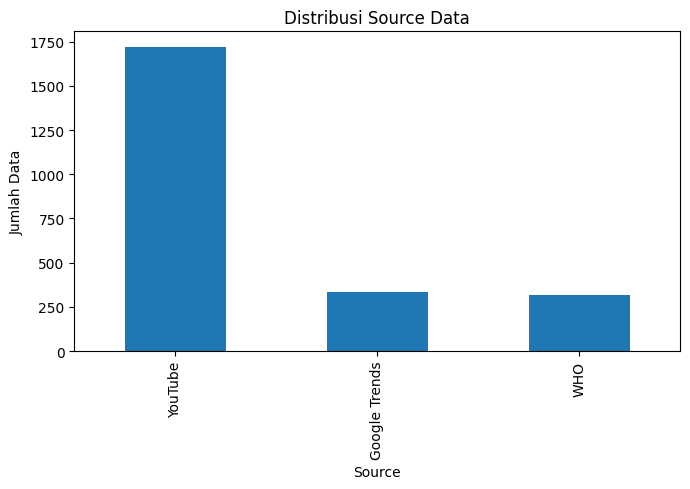

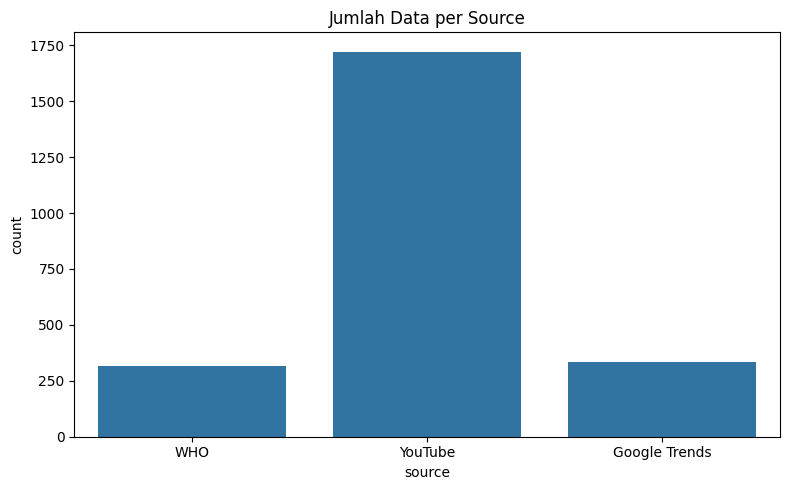

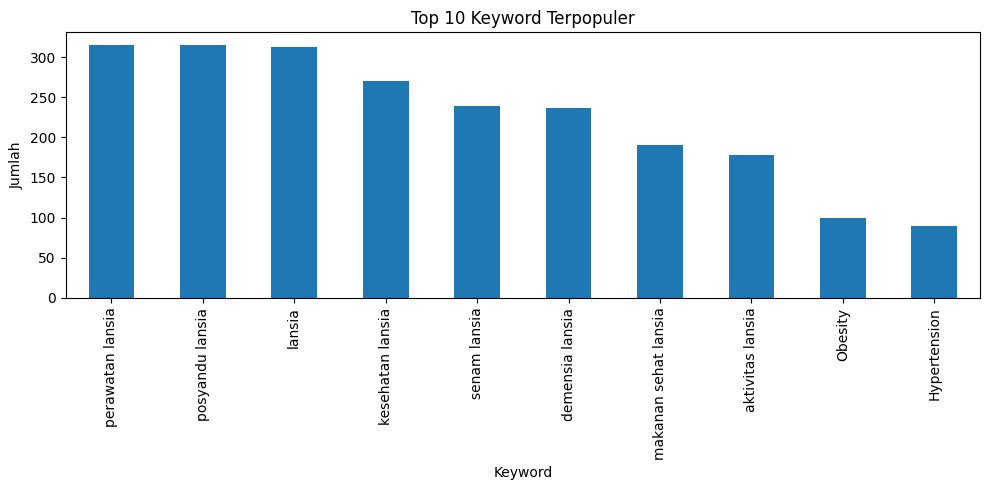

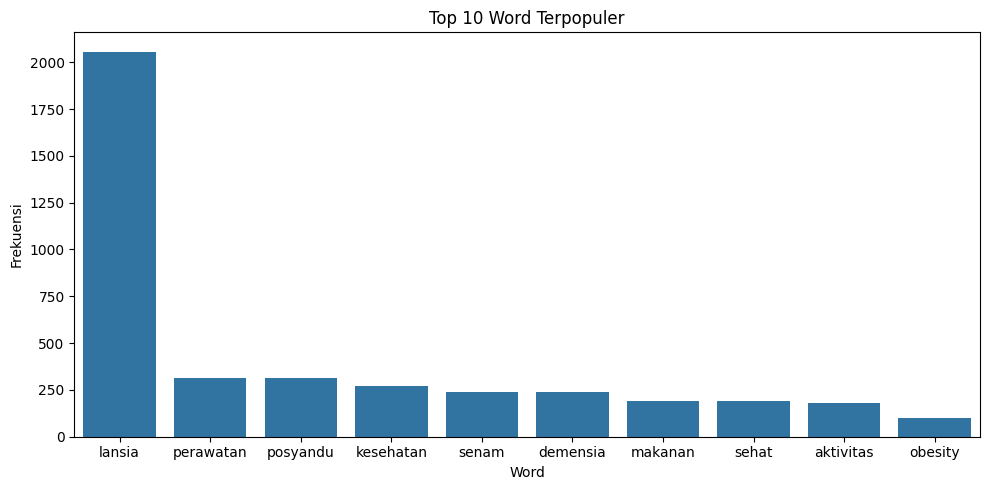

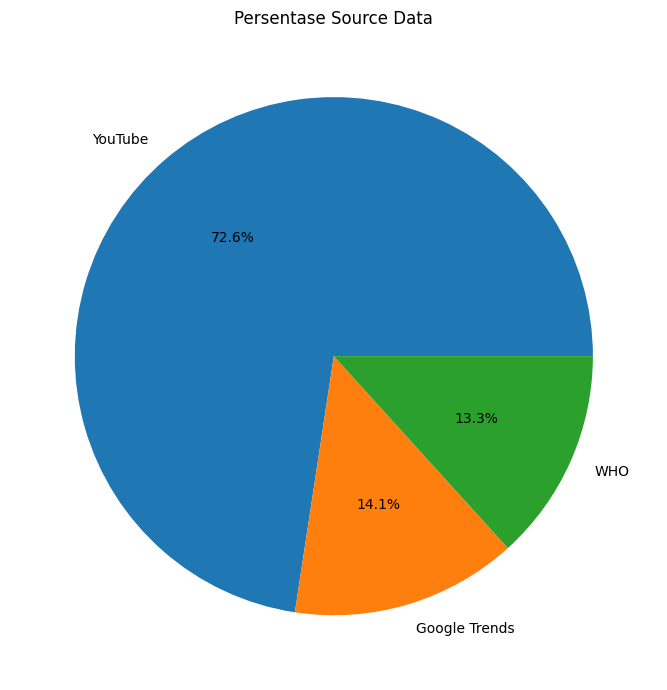

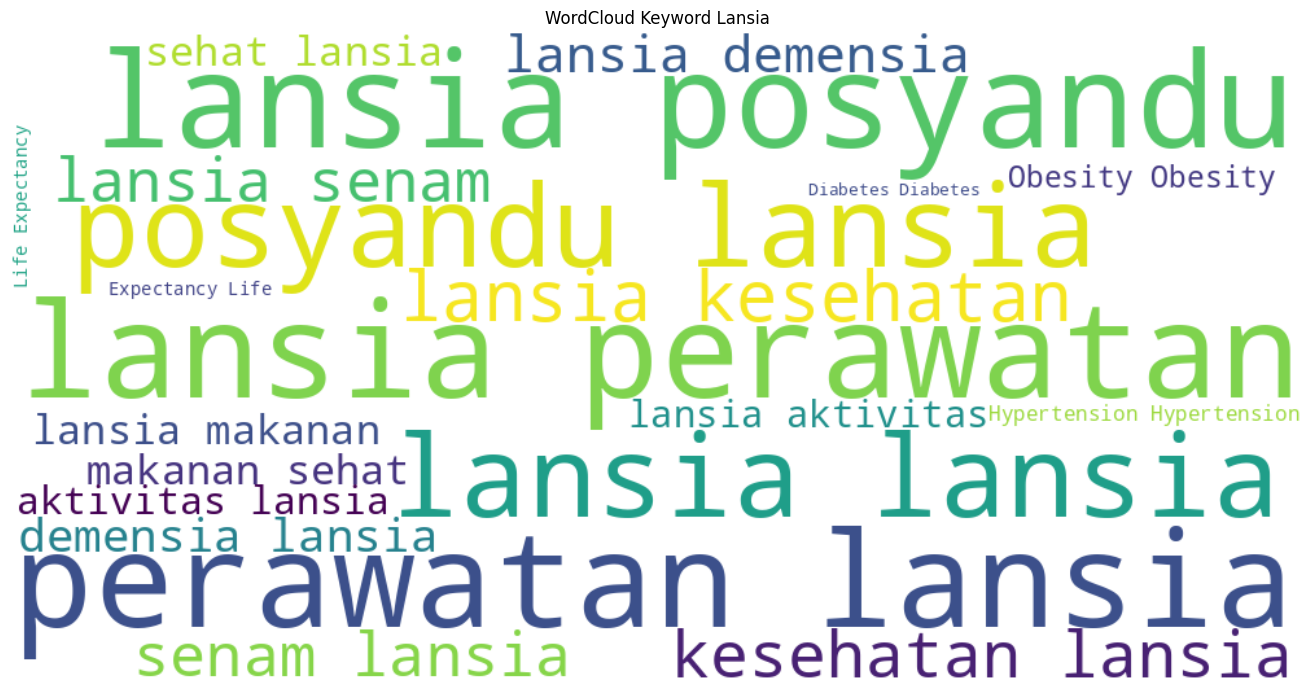





===== HASIL ANALISIS =====

1. Data paling banyak berasal dari source: YouTube

2. Jumlah keyword unik: 12

3. Dataset berhasil menggabungkan data kesehatan, tren pencarian, dan media sosial.

4. Data dapat digunakan untuk mendukung AI caregiver dalam monitoring dan rekomendasi aktivitas lansia.


In [ ]:
# ============================================
# ANALYSIS DATA & VISUALIZATION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import pandas as pd
import re

# ============================================
# CEK DATA
# ============================================

print("\n===== PREVIEW DATA =====")
print(combined.head())

print("\n\n")

# ============================================
# STATISTIK DESKRIPTIF
# ============================================

print("\n===== STATISTIK DESKRIPTIF =====")
print(combined.describe(include="all"))

print("\n\n")

# ============================================
# DISTRIBUSI SOURCE DATA
# ============================================

plt.figure(figsize=(7, 5))

combined["source"].value_counts().plot(kind="bar")

plt.title("Distribusi Source Data")
plt.xlabel("Source")
plt.ylabel("Jumlah Data")

plt.tight_layout()
plt.show()

print("\n\n")

# ============================================
# JUMLAH DATA PER SOURCE
# ============================================

plt.figure(figsize=(8, 5))

sns.countplot(data=combined, x="source")

plt.title("Jumlah Data per Source")

plt.tight_layout()
plt.show()

print("\n\n")

# ============================================
# TOP 10 KEYWORD TERPOPULER
# ============================================

if "keyword" in combined.columns:

    top_keywords = (
        combined["keyword"]
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10, 5))

    top_keywords.plot(kind="bar")

    plt.title("Top 10 Keyword Terpopuler")
    plt.xlabel("Keyword")
    plt.ylabel("Jumlah")

    plt.tight_layout()
    plt.show()

print("\n\n")

# ============================================
# TOP WORD TERPOPULER
# ============================================

if "keyword" in combined.columns:

    text = " ".join(
        combined["keyword"].astype(str)
    )

    words = re.findall(
        r'\w+',
        text.lower()
    )

    word_freq = Counter(words)

    top_words = word_freq.most_common(10)

    word_df = pd.DataFrame(
        top_words,
        columns=["word", "count"]
    )

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=word_df,
        x="word",
        y="count"
    )

    plt.title("Top 10 Word Terpopuler")
    plt.xlabel("Word")
    plt.ylabel("Frekuensi")

    plt.tight_layout()
    plt.show()

print("\n\n")

# ============================================
# DISTRIBUSI DATA BERDASARKAN SOURCE
# ============================================

plt.figure(figsize=(7,7))

combined["source"].value_counts().plot(
    kind="pie",
    autopct='%1.1f%%'
)

plt.title("Persentase Source Data")

plt.ylabel("")

plt.tight_layout()
plt.show()

print("\n\n")

# ============================================
# WORDCLOUD
# ============================================

if "keyword" in combined.columns:

    text = " ".join(
        combined["keyword"].astype(str)
    )

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(15,7))

    plt.imshow(
        wordcloud,
        interpolation='bilinear'
    )

    plt.axis("off")

    plt.title("WordCloud Keyword Lansia")

    plt.tight_layout()
    plt.show()

print("\n\n")

# ============================================
# INSIGHT DATA
# ============================================

print("\n===== HASIL ANALISIS =====")

print(
    "\n1. Data paling banyak berasal dari source:",
    combined["source"].value_counts().idxmax()
)

if "keyword" in combined.columns:

    print(
        "\n2. Jumlah keyword unik:",
        combined["keyword"].nunique()
    )

print(
    "\n3. Dataset berhasil menggabungkan data kesehatan,"
    " tren pencarian, dan media sosial."
)

print(
    "\n4. Data dapat digunakan untuk mendukung "
    "AI caregiver dalam monitoring dan "
    "rekomendasi aktivitas lansia."
)